In [ ]:
from ml_enhance import CorrelationFilter

import matplotlib.pyplot as plt
from sklearn import pipeline
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import scipy
import json

In [2]:
COMBO_DATA = Path("../data/RF_results/RF_combo_results.pkl")
with COMBO_DATA.open("rb") as f:
    combo_results = pickle.load(f)

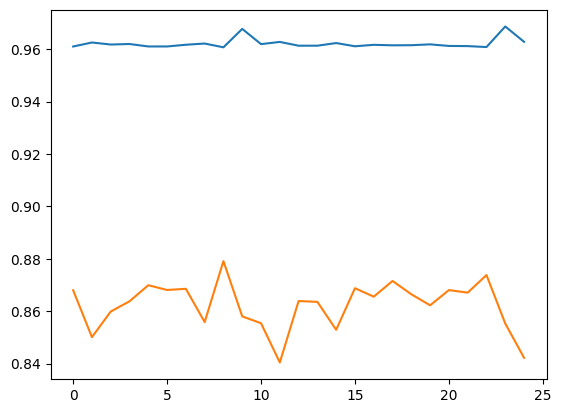

In [10]:
x = range(25)
plt.plot(x, combo_results["train_r2"])
plt.plot(x, combo_results["test_r2"])

In [26]:
best_idx = combo_results["test_r2"].argmax()
best_model = combo_results["estimator"][best_idx]
best_model.best_params_

{'predict__max_depth': 33,
 'predict__max_features': 0.3,
 'predict__min_samples_leaf': 1,
 'predict__min_samples_split': 13,
 'predict__n_estimators': 776}

In [5]:
combo_results["train_r2"].mean(), combo_results["test_r2"].mean()

(np.float64(0.9621412435332876), np.float64(0.8623207995230464))

In [27]:
print("Best score:", best_model.best_score_)
print("Best params:", best_model.best_params_)

Best score: 0.8535919713505005
Best params: {'predict__max_depth': 33, 'predict__max_features': 0.3, 'predict__min_samples_leaf': 1, 'predict__min_samples_split': 13, 'predict__n_estimators': 776}


In [ ]:
topo_r2s = np.abs(scores_topo["test_r2"])
topo_filtered_r2s = np.abs(scores_topo_pure["test_r2"])
combo_r2s = scores_combo["test_r2"]
combo_filtered_r2s = scores_combo_pure2["test_r2"]
# combo_filtered_rfe_r2s = scores_combo_pure_rfe["test_r2"]
# combo_rfe_r2s = scores_combo_rfe["test_r2"]

r2s = np.array([topo_r2s, topo_filtered_r2s, combo_r2s, combo_filtered_r2s])
names = ["topo", "topo_filtered", "topo+QM", "topo+QM_filtered"]
r2_df = pd.DataFrame(r2s.T, columns=names)

r2_df_long = r2_df.melt(var_name="model", value_name="r2")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

order = (
    r2_df_long.groupby("model")["r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

blue_models = ["topo+QM", "topo+QM_rfe", "topo+QM_filtered", "topo+QM_filtered_rfe"]

palette = {
    model: "tab:blue" if model in blue_models else "lightgray"
    for model in r2_df.columns
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df_long,
    x="model",
    y="r2",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df_long,
    x="model",
    y="r2",
    order=order,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df_long, x="model", y="r2", color="black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    # Patch(facecolor="tab:blue", edgecolor="black", label="QM + topo"),
    # Patch(facecolor="lightgray", edgecolor="black", label="Topo-only"),
    Patch(facecolor="tab:red", edgecolor="black", label="Mean ± SD"),
    Patch(facecolor="black", edgecolor="black", label="Individual points", alpha=0.4)
]

plt.legend(handles=[point_handle, strip_handle], loc="lower right", frameon=False, fontsize=12)

plt.xticks(fontsize=16)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Linear model performance comparison", fontsize=16)
# plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()